## Objetivo

O objetivo da feature engineering é transformar dados brutos em inputs (features) que maximizem o desempenho de um modelo de Machine Learning. Seus objetivos específicos são:

1. Melhorar o poder preditivo: o objetivo principal é criar novas variáveis ou transformar as existentes para que o modelo consiga captar relações complexas que não estavam óbvias nos dados originais;

2. Adequar os dados ao algoritmo: cada algoritmo tem premissas matemáticas diferentes. A engenharia de feature serve para "traduzir" os dados para o formato que o algoritmo entende (como transformar variáveis categóricas em numéricas);

3. Reduzir o Overfitting: features irrelevantes ou ruidosas confudem o modelo, fazendo com que ele decore os dados de treino em vez de aprender padrões gerais. A seleção de features mantem apenas as variáveis mais relevantes, removendo redundâncias (multicolinearidade) ou ruídos.

In [1]:
import sys 
import os 

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from src.data_cleaning import data_cleaning
from scipy.stats import f_oneway
import statsmodels.api as sm

In [3]:
df = pd.read_csv('../data/raw/train.csv', sep=',')

In [4]:
df = df.drop('Id', axis=1)

## 1. SalePrice

Como observado em 1_eda.ipynb, a variável SalePrice é right-skewed. Isso acontece porque a maioria dos imóveis possui preços conectrados em faixas menores. Assim, para que a distribuição da variável target se aproxime de uma distribuição normal, vamos realizar a transformação:

$$
    \text{SalePrice} = \log(\text{SalePrice})
$$

In [5]:
df['SalePrice'] = np.log1p(df['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

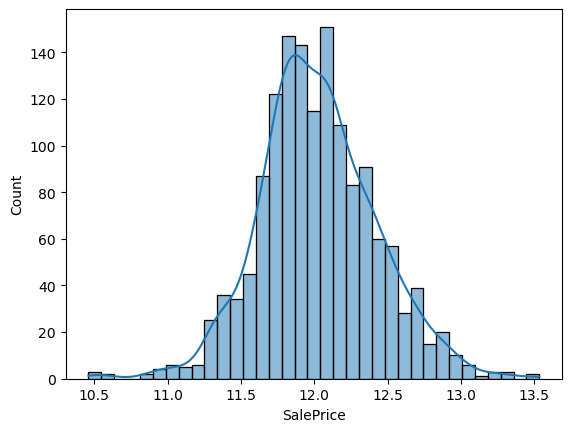

In [6]:
sns.histplot(df['SalePrice'], kde=True)

## 2. Limpando missing values

Vamos analisar o comportamento dos dados ausentes no dataset. Para isso, vamos calcular a porcentagem de dados ausentes em cada uma das colunas.

O primeiro passo é identificar quais colunas possuem dados ausentes:

In [7]:
missing_cols = df.columns[df.isna().sum() > 0]

missing_cols

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

E então calculamos a porcentagem relativa à aquela coluna:

In [8]:
missing_percent = (df[missing_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [ ]:
df = data_cleaning(df)

In [9]:
missing_cols = df.columns[df.isna().sum() > 0]

missing_cols

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [10]:
missing_percent = (df[missing_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

## 3. Encoding de variáveis binárias

Nesta etapa, realizaremos a codificação das variáveis CentralAir e Street, convertendo os valores "No" para 0 e "Yes" para 1, utilizando a função encode_binary(df).


In [11]:
def encode_binary(df):
    df = df.copy()

    binary_cols = {
        "CentralAir": {"N": 0, "Y": 1},
        "Street": {"Grvl": 0, "Pave": 1}
    }

    for col, mapping in binary_cols.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

In [12]:
df = encode_binary(df)

## 4. Encoding das variáveis ordinais:

Nesta etapa, realizaremos a codificação das variáveis ordinais com menos de 10 categorias, que seguem uma ordem de classificação bem definida. Os conjuntos de categorias e suas respectivas ordens são:

- Qualidade com nível "None" (None, Po, Fa, TA, Gd, Ex):

$$
\text{None} < \text{Po} < \text{Fa} < \text{TA} < \text{Gd} < \text{Ex}
$$

- Classificação de acabamento (None, Unf, LwQ, Rec, BLQ, ALQ, GLQ):

$$
\text{None} < \text{Unf} < \text{LwQ} < \text{Rec} < \text{BLQ} < \text{ALQ} < \text{GLQ}
$$

- Severidade (Sal, Sev, Maj2, Maj1, Mod, Min2, Min1, Typ):

$$
\text{Sal} < \text{Sev} < \text{Maj2} < \text{Maj1} < \text{Mod} < \text{Min2} < \text{Min1} < \text{Typ}
$$

- Tipo de acabamento (None, Unf, RFn, Fin):

$$
\text{None} < \text{Unf} < \text{RFn} < \text{Fin}
$$

- Material da garagem (None, MnWw, GdWo, MnPRv, GdPrv):

$$
\text{None} < \text{MnWw} < \text{GdWo} < \text{MnPRv} < \text{GdPrv}
$$

- Zoneamento (IR3, IR2, IR1, Reg):

$$
\text{IR3} < \text{IR2} < \text{IR1} < \text{Reg}
$$

- Inclinação do terreno (Sev, Mod, Gtl):

$$
\text{Sev} < \text{Mod} < \text{Gtl}
$$

- Tipo de via (None, Grvl, Pave):

$$
\text{None} < \text{Grvl} < \text{Pave}
$$


In [13]:
def encode_ordinal(df):
    df = df.copy()

    mapping_qual = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
    mapping_exposure = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
    mapping_finish = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
    mapping_functional = {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7}
    mapping_garage_finish = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
    mapping_fence = {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}
    mapping_lot_shape = {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3}
    mapping_land_slope = {"Sev": 0, "Mod": 1, "Gtl": 2}
    mapping_alley = {"None": 0, "Grvl": 1, "Pave": 2}
    mapping_mas_vnr_type = {"BrkCmnn": 0, "None": 1, "BrkFace": 2, "Stone": 3}

    ordinal_mappings = {
        "ExterQual": mapping_qual,
        "ExterCond": mapping_qual,
        "BsmtQual": mapping_qual,
        "BsmtCond": mapping_qual,
        "KitchenQual": mapping_qual,
        "FireplaceQu": mapping_qual,
        "GarageQual": mapping_qual,
        "GarageCond": mapping_qual,
        "HeatingQC": mapping_qual,
        "BsmtExposure": mapping_exposure,
        "BsmtFinType1": mapping_finish,
        "BsmtFinType2": mapping_finish,
        "Functional": mapping_functional,
        "GarageFinish": mapping_garage_finish,
        "Fence": mapping_fence,
        "LotShape": mapping_lot_shape,
        "LandSlope": mapping_land_slope,
        "Alley": mapping_alley,
        "MasVnrType": mapping_mas_vnr_type,
    }

    for col, mapping in ordinal_mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    return df

In [14]:
df = encode_ordinal(df)

### 5. Neighborhood 

Para a variável nominal Neighborhood, transformaremos em variável contínua através do Score:

$$
    \text{Score} = \frac{1}{2}\text{log(SalePrice)} + \frac{3}{10}\text{OverallQual mean} + \frac{2}{10}\text{YearBuilt}
$$

In [15]:
def compute_neighborhood_score(df):

    neigh = df.groupby("Neighborhood").agg({
        "SalePrice": "mean",
        "OverallQual": "mean",
        "YearBuilt": "mean"
    })

    neigh = neigh.rename(columns={
        "OverallQual": "Qual_mean"
    })

    for col in ["SalePrice", "Qual_mean", "YearBuilt"]:
        neigh[col + "_z"] = (neigh[col] - neigh[col].mean()) / neigh[col].std()

    neigh["Score"] = (
        0.5 * neigh["SalePrice_z"] + 
        0.3 * neigh["Qual_mean_z"] + 
        0.2 * neigh["YearBuilt_z"]
    )

    df = df.copy()
    df["Neighborhood"] = df["Neighborhood"].map(neigh["Score"])

    return df


In [16]:
df = compute_neighborhood_score(df)

### 6. Utilities

A variável utilities é praticamente constante, uma vez que possui somente duas categorias: AllPub e NoSeWa, sendo que a categoria NoSeWa está presente em somente 7% dos dados. Assim, essa variável será descartada do dataset.

In [18]:
df.drop(columns='Utilities')

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,1,NaN,3,Lvl,Inside,2,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,20,RL,80.0,9600,1,NaN,3,Lvl,FR2,2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,60,RL,68.0,11250,1,NaN,2,Lvl,Inside,2,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,70,RL,60.0,9550,1,NaN,2,Lvl,Corner,2,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,60,RL,84.0,14260,1,NaN,2,Lvl,FR2,2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,Inside,2,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547
1456,20,RL,85.0,13175,1,NaN,3,Lvl,Inside,2,...,0,NaN,3.0,NaN,0,2,2010,WD,Normal,12.254868
1457,70,RL,66.0,9042,1,NaN,3,Lvl,Inside,2,...,0,NaN,4.0,Shed,2500,5,2010,WD,Normal,12.493133
1458,20,RL,68.0,9717,1,NaN,3,Lvl,Inside,2,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,11.864469


### 7. Agrupamento de categorias raras

Algumas variáveis possuem categorias com frequência muito baixa. Agruparemos essas categorias com frequência baixa em uma categoria "Other", fazendo:

In [19]:
threshold = [0.005, 0.01, 0.02]

def group_rare_auto(df, cols, threshold):
    df = df.copy()

    for col in cols:
        freq = df[col].value_counts(normalize=True)
        rare = freq[freq < threshold].index

        df[col] = df[col].replace(rare, "Other")

    return df

O threshold será testando com cross-validation para as variáveis:

- Electrical
- Exterior1st
- Exterior2nd
- Heating
- LotConfig
- MSZoning
- MiscFeature
- RoofMatl
- RoofStyle
- SaleCondition
- SaleType
- HouseStyle

Depois de agrupar as categorias raras, iremos realizar one-hot enconding com cross-validation nessas categorias.

### 6. One-hot encoding das variáveis nominais

As variáveis "MSZoning", "LandContour", "Utilities", "LotConfig", "Condition1", "Condition2", "BlgdType", "HouseStyle", "RoofStyle", "RoofMatl", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Heating", "Electrical", "MiscFeature", "SaleType" e "SaleCodition" serão transformadas em variáveis binárias por meio da técnica one-hot encoding.

O one-hot encoding converte variáveis categóricas em um formato numérico adequado para modelos de machine learning. Em vez de atribuir valores arbitrários (como 1, 2, 3) às categorias, essa técnica cria novas colunas binárias (0 ou 1); uma para cada categoria possível. Dessa forma, evita-se que o modelo interprete erroneamente uma ordem ou hierarquia entre as categorias.

Para evitar data leak (vazamento de dados), o one-hot encoding será aplicado separadamente dentro de cada fold do processo de validação cruzada. Isso significa que os parâmetros da codificação (como as categorias presentes) serão aprendidos apenas a partir dos dados de treino de cada fold e, em seguida, aplicados ao respectivo conjunto de validação.

In [ ]:
def one_hot_encode(train_df, test_df, nominal_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_encoded = pd.get_dummies(train_df, columns=nominal_cols, drop_first=False)
    test_encoded = pd.get_dummies(test_df, columns=nominal_cols, drop_first=False)

    train_encoded, test_encoded = train_encoded.align(
        test_encoded, join="left", axis=1, fill_value=0
    )

    return train_encoded, test_encoded

### 7. Variáveis relacionadas a banheiro

Como visto na análise exploratória dos dados, existem muitas variáveis para descrever o banheiro e muitas delas possuem pouca correlação linear com o target. Assim, iremos definir a variável "TotalBathrooms", que é resultado da operação:

$$
    \text{TotalBathrooms} = \text{FullBath} + \frac{1}{2} \times \text{HalfBath} + \text{BsmtFullBath} + \frac{1}{2}\times \text{BsmtHalfBath}
$$

In [20]:
df['TotalBathrooms'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)

In [21]:
df.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699,3.5
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016,2.5
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171,3.5
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405,2.0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547,2.5
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,NaN,3.0,NaN,0,2,2010,WD,Normal,12.254868,3.0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,NaN,4.0,Shed,2500,5,2010,WD,Normal,12.493133,2.0
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,4,2010,WD,Normal,11.864469,2.0


### 8. Variáveis relacionadas a idade da casa

A variável YearRemodAdd diz respeito ao ano em que o cômodo foi reformado, enquanto YearSold diz respeito ao ano de venda, se 

$$
    \text{YearRemodAdd} == \text{YearBuilt},
$$

então a casa nunca foi reformada. Podemos então desenvolver uma variável binária que indica se a casa já foi remorda ou não:

In [22]:
df['Remod'] = np.where(
    df['YearBuilt'] == df['YearRemodAdd'],
    0,
    1
)

e também determinara a idade da casa

In [23]:
df['Age'] = df['YrSold'] - df['YearRemodAdd']

In [24]:
df.drop(columns=['YrSold', 'YearRemodAdd'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,0,2,WD,Normal,12.247699,3.5,0,5
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,NaN,NaN,0,5,WD,Normal,12.109016,2.5,0,31
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,NaN,NaN,0,9,WD,Normal,12.317171,3.5,1,6
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,NaN,NaN,0,2,WD,Abnorml,11.849405,2.0,1,36
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,NaN,NaN,0,12,WD,Normal,12.429220,3.5,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,0,8,WD,Normal,12.072547,2.5,1,7
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,3.0,NaN,0,2,WD,Normal,12.254868,3.0,1,22
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,4.0,Shed,2500,5,WD,Normal,12.493133,2.0,1,4
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,NaN,NaN,0,4,WD,Normal,11.864469,2.0,1,14


### 9. OpenPorchSF

Existem quatro variáveis relacionadas a varanda: OpenPorchSF, EnclosedPorch, 3SsnPorch e ScreenPorch. Vimos na análise exploratória dos dados que transforma-las em uma variável TotalPorch faz com que a correlação caia drasticamente.

In [ ]:
df.drop(columns=['EnclosedPorch', '3SsnPorch', 'ScreenPorch'])

### 10. PoolQC

A variável PoolQC (qualidade da piscina) será convertida em uma variável binária indicando apenas se a residência possui piscina ou não. Os valores originais "Ex" (Excelente), "Fa" (Regular/Fair) e "Gd" (Bom/Good) serão agrupados em uma única categoria representando presença de piscina (codificada como 1). Já os valores "None" e quaisquer dados faltantes (NaN) indicam que a residência não possui piscina e serão codificados como 0. Dessa forma, a nova coluna binária resume de maneira eficaz a informação relevante para o modelo.

In [25]:
def binarize_poolqc(df, col_name='PoolQC', new_col_name='has_pool'):

    pool_categories = ['Ex', 'Fa', 'Gd']
    
    df[new_col_name] = df[col_name].apply(
        lambda x: 1 if x in pool_categories else 0
    )
    df[new_col_name] = df[new_col_name].fillna(0).astype(int)
    
    return df

In [26]:
df = binarize_poolqc(df)

### 11. MiscFeature

A variável MiscFeature possui a grande maioria dos dados vazios. Assim, vamos transformar MiscFeature em uma variável binária onde 0 representa a ausência de Miscfeature e 1 representa a presença de MiscFeature.


In [27]:
def binarize_miscfeature(df, col_name='MiscFeature', new_col_name='has_misc_feature'):

    misc_feature_categories = ['Shed', 'Gar2', 'Othr', 'TenC']
    
    df[new_col_name] = df[col_name].apply(
        lambda x: 1 if x in misc_feature_categories else 0
    )
    df[new_col_name] = df[new_col_name].fillna(0).astype(int)
    
    return df

In [28]:
df = binarize_miscfeature(df)

### 12. KitchenQual

A variável KitchenQual já é determinada por KitchenAbvGr. Como visto na análise exploratória dos dados, casas com mais de uma cozinha tendem a ter KitchenQual menor. Assim, iremos eliminar essa variável.

In [29]:
df.drop(columns='KitchenQual')

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age,has_pool,has_misc_feature
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,2,2008,WD,Normal,12.247699,3.5,0,5,0,0
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,5,2007,WD,Normal,12.109016,2.5,0,31,0,0
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,9,2008,WD,Normal,12.317171,3.5,1,6,0,0
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,11.849405,2.0,1,36,0,0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,12,2008,WD,Normal,12.429220,3.5,0,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,8,2007,WD,Normal,12.072547,2.5,1,7,0,0
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,2,2010,WD,Normal,12.254868,3.0,1,22,0,0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,5,2010,WD,Normal,12.493133,2.0,1,4,0,1
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,4,2010,WD,Normal,11.864469,2.0,1,14,0,0


### 13. TotRmsAbvGrd, GarageYrBlt e GarageArea

Como interpretado na EDA, iremos excluir as colunas TotRmsAbvGrd, GarageYrBlt e GarageArea

In [30]:
df.drop(columns=['TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age,has_pool,has_misc_feature
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,2,2008,WD,Normal,12.247699,3.5,0,5,0,0
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,5,2007,WD,Normal,12.109016,2.5,0,31,0,0
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,9,2008,WD,Normal,12.317171,3.5,1,6,0,0
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,11.849405,2.0,1,36,0,0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,12,2008,WD,Normal,12.429220,3.5,0,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,8,2007,WD,Normal,12.072547,2.5,1,7,0,0
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,2,2010,WD,Normal,12.254868,3.0,1,22,0,0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,5,2010,WD,Normal,12.493133,2.0,1,4,0,1
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,4,2010,WD,Normal,11.864469,2.0,1,14,0,0


### 14. 1stFlrSF e 2ndFlrSF

Essas duas variáveis são explicadas pelas demais variáveis de área da casa, assim, podem ser descartadas.

In [31]:
df.drop(columns=['1stFlrSF', '2ndFlrSF'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age,has_pool,has_misc_feature
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,2,2008,WD,Normal,12.247699,3.5,0,5,0,0
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,5,2007,WD,Normal,12.109016,2.5,0,31,0,0
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,9,2008,WD,Normal,12.317171,3.5,1,6,0,0
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,11.849405,2.0,1,36,0,0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,12,2008,WD,Normal,12.429220,3.5,0,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,8,2007,WD,Normal,12.072547,2.5,1,7,0,0
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,2,2010,WD,Normal,12.254868,3.0,1,22,0,0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,5,2010,WD,Normal,12.493133,2.0,1,4,0,1
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,4,2010,WD,Normal,11.864469,2.0,1,14,0,0


### 15. PoolArea

Como investigado na análise exploratória dos dados, a área da piscina não influencia tanto quanto a sua presença. Logo, a variável será eliminada.

In [32]:
df.drop(columns=['PoolArea'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age,has_pool,has_misc_feature
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,2,2008,WD,Normal,12.247699,3.5,0,5,0,0
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,5,2007,WD,Normal,12.109016,2.5,0,31,0,0
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,9,2008,WD,Normal,12.317171,3.5,1,6,0,0
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,2,2006,WD,Abnorml,11.849405,2.0,1,36,0,0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,12,2008,WD,Normal,12.429220,3.5,0,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,8,2007,WD,Normal,12.072547,2.5,1,7,0,0
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,2,2010,WD,Normal,12.254868,3.0,1,22,0,0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,5,2010,WD,Normal,12.493133,2.0,1,4,0,1
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,4,2010,WD,Normal,11.864469,2.0,1,14,0,0


### 16. Foundation

O tipo de fundação está intimamente ligado a idade da casa. Como vimos anteriormente, casas mais possuem fundação com material "PConc", enquanto casas de criadas entre 1940 e 1980, material "CBlock" e, casas de idade anterior a 1940, material "BrkTil". Assim, podemos classificar os demais materiais como "Others" e fazer o mapeamento da seguinte forma:

In [33]:
def encode_foundation(df: pd.DataFrame) -> pd.DataFrame:

    mapping_foundation = {'BrkTil': 1, 'CBlock': 2, 'PConc': 3}
    df['Foundation'] = df['Foundation'].map(mapping_foundation).fillna(0).astype(int)
    return df

In [34]:
df = encode_foundation(df)

### 17. MoSold

O mês de venda tem mais carater exploratório do que preditivo, por isso será descartada.

In [35]:
df.drop(columns=['MoSold'])

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscVal,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,Remod,Age,has_pool,has_misc_feature
0,60,RL,65.0,8450,1,NaN,3,Lvl,AllPub,Inside,...,0,2008,WD,Normal,12.247699,3.5,0,5,0,0
1,20,RL,80.0,9600,1,NaN,3,Lvl,AllPub,FR2,...,0,2007,WD,Normal,12.109016,2.5,0,31,0,0
2,60,RL,68.0,11250,1,NaN,2,Lvl,AllPub,Inside,...,0,2008,WD,Normal,12.317171,3.5,1,6,0,0
3,70,RL,60.0,9550,1,NaN,2,Lvl,AllPub,Corner,...,0,2006,WD,Abnorml,11.849405,2.0,1,36,0,0
4,60,RL,84.0,14260,1,NaN,2,Lvl,AllPub,FR2,...,0,2008,WD,Normal,12.429220,3.5,0,8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,1,NaN,3,Lvl,AllPub,Inside,...,0,2007,WD,Normal,12.072547,2.5,1,7,0,0
1456,20,RL,85.0,13175,1,NaN,3,Lvl,AllPub,Inside,...,0,2010,WD,Normal,12.254868,3.0,1,22,0,0
1457,70,RL,66.0,9042,1,NaN,3,Lvl,AllPub,Inside,...,2500,2010,WD,Normal,12.493133,2.0,1,4,0,1
1458,20,RL,68.0,9717,1,NaN,3,Lvl,AllPub,Inside,...,0,2010,WD,Normal,11.864469,2.0,1,14,0,0


## Classificação das colunas por tipo

Grupo de variáveis relacionadas a área / dimensões:

- LotArea: tamanho da propriedade
- MasVnrArea: área de revestimento de alvenaria
- GrLivArea: área habitável acima do solo 
- GarageArea: tamanho da garagem 
- PoolArea: tamanho da piscina
- BsmtFinSF2: área construída do tipo 2
- BsmtUnfSF: área inacabada do porão
- TotalBsmtSF: área total do porão 
- 1stFlrSF: metragem (em pés quadrados) do primeiro piso 
- 2ndFlrSF: metragem em pés quadrados do segundo piso 
- WoodDeckSF: área do deck de madeira em pés quadrados
- OpenPorchSF: varanda aberta (em pés quadrados)
- EnclosedPorch: varanda fechada (em pés quadrados)
- 3SsnPorch: varanda de três estações (em pés quadrados)
- ScreenPorch: varanda tela (em pés quadrados)
- BedroomAbvGrv: quantidade de quartos acinma do nível do solo
- BldgType: tipo de habitação
- KitchenAbvGrv: cozinhas quantidade de cozinhas acima do nível do solo
- TotRmsAbvGrd: quantidade total de quartos acima do nível do solo

Grupo de variáveis relacionadas a qualidade / condição:

- OverallQual: avaliação do material e acabamento geral da casa
- OverallCond: avaliação do estado geral da casa
- ExterQual: qualidade do material no exterior
- ExterCond: estado atual do material no exterior
- HeatingQC: condição da qualidade do sistema de aquecimento
- LowQualFinSF: baixa qualidade da área construída
- FireplaceQu: qualidade das lareiras
- GarageQual: qualidade da garagem
- PoolQC: qualidade da piscina
- Fence: qualidade da cerca
- Exterior1st: cobertura externa da casa
- Exterior2st: cobertura externa da casa se houver mais de uma
- Foundation
- HouseStyle
- KitchenQual: qualidade da cozinha
- MSSubClass: identifica o tipo de imóvel envolvido na venda
- MasVnrType: tipo de revestimento de alvenaria

Grupo de variáveis relacionadas a localização:

- MSZoning: identifica a classificação geral de zoneamento da área de venda
- LotFrontage: metros lineares de rua conectados à propriedade
- Street: tipo de acesso rodoviário à propriedade
- Alley: tipo de acesso ao imóvel pelo beco
- Neighborhood: localização física dentro dos limites da cidade de Ames
- Condtion1: proximidade de determinadas condições
- Condition2: proximidade de determinadas condições se houver mais de uma 
- LotShape: formato do terreno do imóvel 
- LandContour: planicidade da propriedade
- LotConfig: configuração do lote (se é de esquina, sem saída, ...)
- LandSlope: inclinação do terreno

Grupo de variáveis relacionadas a garagem:

- GarageType: localização da garagem
- GarageYrBlt: ano em que a garagem foi construída
- GarageFinish: interior da garagem finalizado
- GarageCars: quantidade de carros que cabem na garagem
- GarageArea: tamanho da garagem em pés quadrados
- GarageQual: qualidade da garagem
- GarageCond: condição da garagem

Grupo de variáveis relacionadas ao porão:

- BsmtQual: avalia a altura do porão
- BsmtCond: avalia a condição do porão
- BsmtExposure: refere-se a paredes com saída para o exterior ou ao nível do jardim
- BsmtFinType1: classificação da área acabada do porão
- BsmtFinSF1: tamanho em pés quadrados do tipo 1
- BsmtFinType2: classificação da área acabada do porão (se houver vários tipos)
- BsmtFinSF2: área construída do tipo 2
- BsmtUnfSF: área em pés quadrados inacabada do porão
- TotalBsmtSF: área total do porão em pés quadrados
- BsmtFullBath: banheiros completos no porão
- BsmtHalfBath: lavabos completos no porão

Grupo de variáveis relacionadas a utilidades:

- Heating
- HeatingQC
- CentralAir
- Eletrical
- Functional
- Fireplaces 
- PavedDrive
- PoolQC
- Fence
- MiscFeature
- MiscVal
- Utilities

Grupo de variáveis relacionadas a piscina:

- PoolArea: área da piscina 
- PoolQC: qualidade da piscina

Grupo de variáveis relacionadas ao telhado:

- RoofStyle: tipo de telhado
- RoofMatel: material do telhado

Grupo de variáveis relacionadas a idade:

- MoSold: mês da venda
- YrSold: ano da venda
- GarageYtBlt: ano em que a garagem foi construída
- YearBuilt: ano de construção original da casa
- YearRemodAdd: ano de recuperação ou adição de cômodos na casa

Grupo de variáveis relacionadas a banheiro:

- Banheiros completos no porão
- BsmtHalfBath: lavabos no porão
- FullBath: banheiros completos acima do nível do solo
- HalfBath: lavabos acima do nível do solo

Grupo de variáveis relacionadas a venda:

- SaleCondition
- SaleType